# 论文基本信息

| 项目        | 内容                                                                                  |
| :-------- | :---------------------------------------------------------------------------------- |
| **标题**    | On the Direction of RLVR Updates for LLM Reasoning: Identification and Exploitation |
| **作者**    | Kexin Huang, Haoming Meng, Junkang Wu, Jinda Lu 等                                   |
| **机构**    | Qwen Pilot Team, Alibaba Group                                                      |
| **arXiv** | 2603.22117(https://arxiv.org/abs/2603.22117)                                      |
| **发表时间**  | 2026年3月                                                                             |
| **核心主题**  | <font color='red'>从"方向"而非"幅度"的**视角分析** RLVR（可验证奖励强化学习）的更新机制</font>                                               |

# 研究背景与核心问题

## RLVR 的现状
RLVR（Reinforcement Learning with Verifiable Rewards）是当前提升 LLM 推理能力的主流范式——从 DeepSeek-R1 到 Qwen 的推理模型，都依赖 RLVR 让模型在数学、代码等可验证任务上自我进化。

## 现有分析的盲区
已有研究指出，RLVR 对模型分布的修改是稀疏的——只影响少数 token。 <font color='red'>但这些分析主要关注幅度（magnitude）</font>，比如：
- 熵（Entropy）：哪些位置的分布最不确定？
- KL 散度：新旧策略在哪些位置差异最大？
  - "While existing analyses identify that RLVR-induced changes are sparse, they primarily focus on the magnitude of these updates, largely overlooking(忽视) their direction." 
  
## 核心洞察
**幅度大 ≠ 推理关键**。
- 一个 token 的 KL 散度可能很大，但这<font color='red'>只说明新旧策略"不一样"</font>，**并不说明 RLVR 是在增强推理还是破坏推理**。
- <font color='red'>真正重要的是方向</font>——<font color='blue'>RLVR 是把这个 token 的概率推高了还是压低了。</font>

# 核心度量：Δlog p
## 定义

In [1]:
from IPython.display import Image

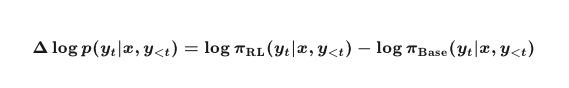

In [4]:
Image(filename='./Image/logp.png')

| 符号                  | 含义               |
| :------------------ | :--------------- |
| π_Base | 基础模型（SFT 模型）     |
| π_RL   | RLVR 训练后的模型      |
| $y_t$               | 序列中第 $t$ 个 token |
| $x$                 | prompt           |


## 直观解读
- Δlog p > 0：RLVR 模型比基础模型<font color='red'>更偏好</font>这个 token → **RLVR "学会"了它**
- Δlog p < 0：RLVR 模型比基础模型<font color='red'>更排斥</font>这个 token → **RLVR "抛弃"了它**
- Δlog p ≈ 0：RLVR 没怎么动这个 token

## <font color='red'>为什么它比幅度指标更好？</font>

论文对比了三种指标在多个 RLVR-Base 模型对上的分布：


| 指标         | 对 Base/RL 的区分能力 | 问题                               |
| :--------- | :-------------- | :------------------------------- |
| **熵**      | ❌ 两者分布几乎相同      | 只量"不确定性"，不区分是谁的不确定性              |
| **KL 散度**  | ❌ 两者分布几乎相同      | 只量"差异大小"，不告诉谁变大了                 |
| **Δlog p** | ✅ 明显的双峰分布       | <font color='red'>**有符号**，能区分"RLVR 推高的"和"RLVR 压低的"</font> |

  - "the entropy and KL divergence distributions are nearly identical for both the base and RLVR model outputs. In contrast, the Δlog p distribution exhibits two distinct tails." 


# 验证：Token 替换干预实验
为了验证 Δlog p 确实捕捉到了推理关键 token，论文设计了一个干预实验：

## 实验设计
阈值: 最少替换即可达到 RLVR 水平

In [ ]:
基础模型生成序列时：
    对于每个位置 t：
        如果某个指标（如 Δlog p）超过阈值：
            将该位置的 token 替换为 RLVR 模型的选择
        否则：
            保持基础模型的原始 token

## 结果

| 选择标准                                 | 用最少替换达到 RLVR 性能？       |
| :----------------------------------- | :--------------------- |
| 高熵位置                                 | ❌ 需要大量替换               |
| 高 KL 散度位置                            | ❌ 需要大量替换               |
| **大负 Δlog p 位置**（即 RLVR 强烈压低的 token） | ✅ **最少替换即可达到 RLVR 水平** |


  - "selecting by Δlog p reaches RLVR-level performance with the fewest substitutions, pinpointing tokens where RLVR learns reasoning-critical updates." 

这说明：**RLVR 的推理提升，集中在少数被它"强烈修正"的 token 上。Δlog p 精准定位了这些位置**

# 核心发现：高 Δlog p 对应低概率 Token
论文进一步揭示了一个反直觉的规律：
  - <font color='red'>RLVR 最大的更新（高 Δlog p），发生在低概率 token 上。</font>


## 统计验证
将 token 按 Δlog p 分组后观察：
  - 高 Δlog p 组：<font color='red'>这些 token 在 Base 和 RL 模型中的概率都很低</font>
  - 但这些 token 从 Base 到 RL 的概率增幅最大
  
### 这个发现具体在说什么？
#### 实验设计
论文把所有 token 按照 Δlogp （RLVR 相对 Base 的对数概率变化）分成若干组，比如：  

| 分组      | Δlogp 范围 | 含义            |
| :------ | :----------------- | :------------ |
| 最低组     | 大幅负数（如 < -2）       | RLVR **强烈压低** |
| 中间组     | 接近 0               | RLVR **没怎么动** |
| **最高组** | **大幅正数（如 > +2）**   | RLVR **强烈推高** |

然后观察每一组 token 在 Base 模型 和 RLVR 模型 中的原始概率分布。
  
#### 发现的结果
- 高 Δlogp  组：这些 token 在 Base 模型中的概率本来就很低（比如 $10^{−4}$量级），在 RLVR 模型中的概率依然不高（比如 $10^{−2}$量级）
- <font color='red'>但它们的相对增幅是最大的</font>——**从 Base 到 RL，概率可能提升了 100 倍甚至 1000 倍**
  - 打个比方：
    - Base 模型认为某个 token 出现的概率是 0.01%（几乎不可能），
    - RLVR 把它提升到了 1%（不太可能，但不再荒谬）。
    - <font color='red'>绝对值仍然很小，但相对变化是 100 倍</font>

### 为什么这个发现"反直觉"？
#### 直觉上的错误预期
<font color='red'>人们通常会认为：RLVR 学会的东西，应该是那些本来就有一定基础概率的 token。</font>比如：
  - Base 模型认为"因此"的概率是 15%
  - RLVR 把它提升到 45%
  - 这看起来是"在已有基础上强化"
  
#### 实际发现
<font color='red'>论文发现 RLVR 真正的学习发生在概率极低的区域：</font>
  - Base 模型认为某个推理关键 token（如特定的数学符号、罕见的推理连接词）的概率是 0.001%
  - RLVR 通过训练，把它提升到了 0.1%
  - <font color='blue'>虽然绝对概率依然很低，但模型开始"考虑"这些 token 了</font>
这就像：
  - 一个学生原来做数学题时，脑子里完全不会想到某个高级定理（概率≈0）。
  - 经过训练后，他虽然还是很少用这个定理，但偶尔会想到了（概率>0）。
  - <font color='red'>这个"从不可能到可能"的跨越，就是推理能力提升的关键。</font>

### 背后的机制：为什么低概率 token 是"金矿"？
####  梯度信号的集中性
在策略梯度（如 PPO、GRPO）中，token y_t的梯度大致为：

$∇_{θ}logπ_\theta (y_t) \cdot A_t$


- 对于高概率 token：
  - $∇_{θ}logπ_\theta (y_t) $  很小（因为概率已经很高，对数概率的梯度饱和）
  - <font color='red'>即使优势 $A_t$很大，梯度更新也很微弱</font>
  - **相当于"微调一个已经很确定的选择"**

- 对于低概率 token：
  - $∇_{θ}logπ_\theta (y_t) $ 很大（<font color='red'>概率低意味着对数概率对参数变化很敏感</font>）
  - 一旦优势$ A_t$ 为正（即这个 token 确实带来了好结果），梯度会强力推动概率上升
  - 相当于"发现了一个被忽略的宝藏，大幅调整参数去记住它"
  
#### 概率低意味着对数概率对参数变化很敏感

##### **核心公式**
对于策略 $π_θ(a)$ ，对数概率的梯度为：

$∇_\theta log\pi\theta(a) = \frac{1}{π_θ(a)} \cdot ∇_θπ_θ(a)$

| 概率 $\pi_\theta(a)$ | 系数 $\frac{1}{\pi_\theta(a)}$ | 含义                         |
| :----------------: | :--------------------------: | :------------------------- |
|         0.5        |               2              | 对数概率梯度 = 2 × 概率梯度          |
|        0.01        |            **100**           | 对数概率梯度 = **100 ×** 概率梯度    |
|       0.0001       |          **10,000**          | 对数概率梯度 = **10,000 ×** 概率梯度 |





**概率越低， $\frac{1}{π}$ 越大，对数概率对参数的敏感度越高。**

##### 具体例子：一个二分类决策
假设模型要在两个动作中选一个：

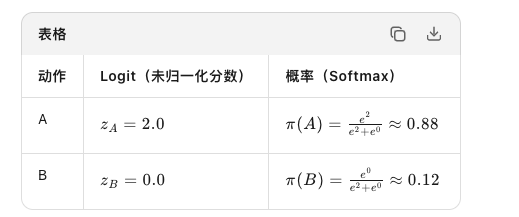

In [10]:
Image(filename='./Image/log1.png')

现在，让 $z_B$增加一个很小的量 Δ=0.1 ：

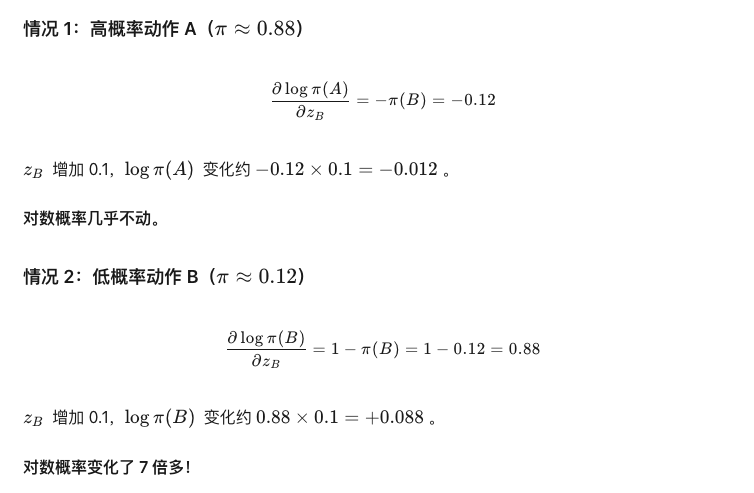

In [11]:
Image(filename='./Image/log2.png')

##### 更极端的情况
把 B 的概率压到极低：

| 动作 |  Logit |            概率           |
| :- | :----: | :---------------------: |
| A  |  5.0 |  π(A) ≈ 0.993 |
| B  | -2.0 | π(B) ≈ 0.0009 |



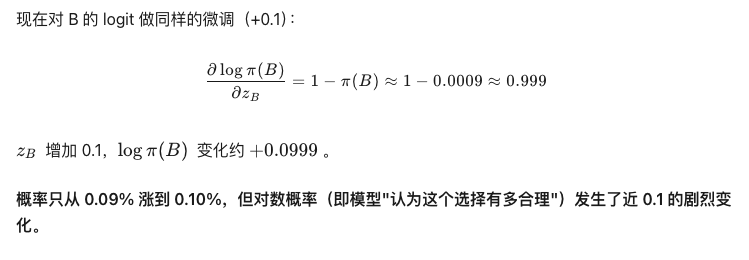

In [12]:
Image(filename='./Image/log3.png')

##### 直观类比：温度计 vs 地震仪

|          | 高概率 token        | 低概率 token                              |
| :------- | :--------------- | :------------------------------------- |
| **类比**   | 室温计              | 地震仪                                    |
| **常态读数** | 稳定在某个值附近         | 几乎为零                                   |
| **微小扰动** | 指针微微晃动           | **指针剧烈摆动**                             |
| **含义**   | 模型已经很确定，微调参数影响不大 | 模型原本"看不见"这个选项， slightest 参数变化就让它"注意到了" |


##### 在 RLVR 中的意义
回到论文的发现：
  - 低概率 token 的 Δlogp  最大。
  
这意味着：
  - RLVR 对这些 token 的参数做了微小但精准的调整
  - 这些调整在对数概率空间中产生了巨大的相对变化
  - <font color='red'>模型开始"考虑"这些以前完全忽略的 token，从而解锁新的推理路径</font>
  
**一句话总结：**
- 低概率 token 就像被埋在深土里的种子——只要参数轻轻一拨（对数概率的微小变化），它就能破土而出（概率从 0 到可感知），带来推理能力的质变。

#### 探索-利用的视角
Base 模型（经过 SFT）已经学会了"常规解法"
  - <font color='red'>那些高概率 token 就是"常规解法"的组成部分。</font>

RLVR 的作用相当于探索：
  - **在大量采样中，模型偶尔（因为温度采样、top-p 等）生成了包含"非常规但有效"token 的序列**
  - 这些序列如果得到了高奖励（答案正确），RLVR 就会强化这些 token
  - 这些 token 原本概率极低，所以 Δlogp  极大
  
#### 为什么绝对概率仍然很低？
- 因为词汇表很大（几万到几十万 token），即使 RLVR 学会了某个关键 token，它的概率也只是<font color='red'>从"几乎不可能"变成"偶尔可能"</font>。在 softmax 的竞争中，它仍然面临大量高频词的竞争。
- 但这已经足够了——**推理不需要每个位置都选最可能的词，只需要在关键位置"想到"正确的词。**

### 因果验证：Top-p 过滤实验
<font color='red'>为了证明"低概率 token 不是噪声，而是关键"，论文做了因果实验：</font>

| Top-p 阈值                | 效果          |
| :---------------------- | :---------- |
| 1.0（不过滤，保留所有 token）     | 正常训练，性能最佳   |
| 0.95（过滤掉概率最低的 5% token） | **性能显著下降**  |
| 0.9（过滤掉概率最低的 10% token） | **性能进一步下降** |

#### 含义
<font color='red'>如果在 RLVR 训练时，用 top-p 采样提前过滤掉低概率 token，模型就学不到这些关键推理信号了。</font>

这说明：
  - 低概率 token 不是训练中的"噪声"或"干扰"
  - <font color='red'>它们是 RLVR 获得推理能力的必要来源</font>
  - 没有这些 token，模型只能在高概率区域"原地打转"，无法突破 Base 模型的能力边界
  
### 对 RLVR 训练的启示
#### 启示 1：<font color='red'>不要过早截断探索</font>
  - 很多 RLVR 实现为了稳定性，会使用很低的温度（如 T=0.6 ）或很小的 top-p（如 0.9）。
    - 论文暗示这可能扼杀了学习空间——**
    模型永远看不到那些低概率但关键的 token，也就无法学会它们。**
    
#### 启示 2：<font color='red'>小概率 ≠ 不重要</font>
  - 在分析 RLVR 行为时，不能只看"RLVR 模型给哪个 token 最高概率"，**而要看"相对于 Base，RLVR 改变了什么"**。
    - 一个 token 在 RLVR 中概率只有 0.5%，但如果 Base 中它是 0.005%，这就是100 倍的推理关键更新。
#### 启示 3：训练时主动加权（重加权方法）
  - 基于这个发现，论文提出了训练时的概率感知优势重加权：

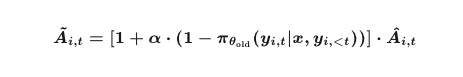

In [9]:
Image(filename='./Image/Reweighting.png')

- 对低概率 token（$π_{old}$≈0 ）：优势被放大 1+α  倍
- 对高概率 token<font color='red'>（$π_{old}$≈1 ）</font>：优势基本不变
这相当于告诉优化器："请特别关注那些旧策略认为不太可能、但可能蕴含推理突破的 token。"

实验表明，这种重加权在 Qwen2.5-Math-7B 和 Qwen3-8B 上均显著提升了 AIME 等基准的通过率。

### 一句话总结
- RLVR 的推理突破，不是发生在"把已经很会的技能练得更精"（高概率 token 的微调），而是发生在"把原本完全不会的技能学会一点点"（低概率 token 的从 0 到 1）。
  - 这些 token 虽然绝对概率依然很低，<font color='red'>但它们是模型跳出 Base 模型能力边界、实现推理跃迁的关键杠杆。</font>

## 因果验证：Top-p 过滤实验
如果在 RLVR 训练时用 top-p 采样过滤掉低概率 token（如 p=0.95 甚至 0.9）：

| Top-p    | 性能    |
| :------- | :---- |
| 1.0（不过滤） | 基准性能  |
| 0.95     | 显著下降  |
| 0.9      | 进一步下降 |

  - "Even a mild filter (e.g., top-p=0.95) leads to a substantial drop in performance...these low-probability tokens are not merely correlated with gradient size but are essential for the reasoning improvements." 
  
### 结论：
- <font color='red'>低概率 token 不是噪声，而是 RLVR 学习的"金矿"——它们承载了推理的关键信号。</font>

# 应用一：测试时外推（Test-Time Extrapolation）
## 核心思想
<font color='red'>既然 Δlog p 标识了从 Base 到 RLVR 的"推理方向"，那能不能继续沿着这个方向走，让 RLVR 模型变得更强？</font>

## 外推策略

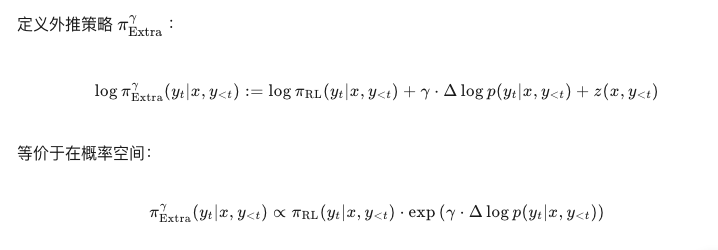

In [5]:
Image(filename='./Image/Extrapolation.png')

| 参数         | 作用                          |
| :--------- | :-------------------------- |
| $\gamma$   | 外推强度，$\gamma=0$ 就是原 RLVR 模型 |
| $z(\cdot)$ | log-partition 函数，保证概率归一化    |


## 为什么需要"选择性"外推？
RLVR 的更新是稀疏的
- <font color='red'>大多数位置的 Δlog p ≈ 0。全局外推会扭曲这些已经校准良好的 token。因此只在 Δlog p 显著为负的位置（即 RLVR 强烈修正的位置）应用外推。</font>


## 理论保证
在简化的 tabular softmax + Natural Policy Gradient 设定下，论文证明了：
  - "There exists γ>0  such that the extrapolated policy achieves expected reward no less than the original RLVR policy." 
  
## 实验结果
在 AIME-24 上，对 ORZ-32B、DAPO-32B、UniReason-14B 进行测试：

# 应用二：训练时优势重加权（Training-Time Reweighting）
## 核心思想

测试时外推需要同时加载 Base 和 RL 两个模型，成本高。
- <font color='red'>能不能在训练时就让模型自己学会关注这些关键 token？</font>

论文利用"<font color='red'>高 Δlog p ↔ 低概率 token</font>"的关联，设计了一种**概率感知优势重加权**：


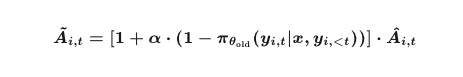

In [6]:
Image(filename='./Image/Reweighting.png')

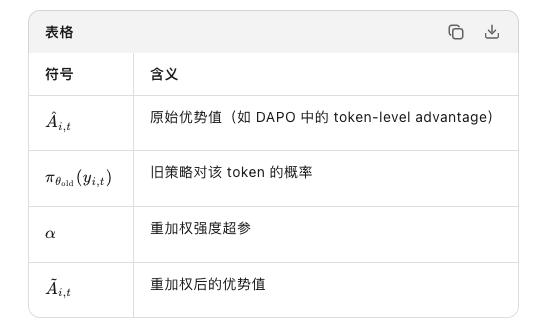

In [8]:
Image(filename='./Image/reweighting2.png')

## 直观解读
- 低概率 token（$π_{old}$≈0 ）：重加权系数 ≈ 1+α ，<font color='red'>优势被放大</font>
- 高概率 token（$π_{old}$≈1 ）：重加权系数 ≈ 1 ，优势基本不变
<font color='red'>这相当于告诉模型："那些在旧策略看来不太可能、但 RLVR 最终学会推高的 token，请给予更多关注。"</font>

## 实验结果
在 Qwen2.5-Math-7B 和 Qwen3-8B-Base 上，与 DAPO 基线对比：

| 模型              | 方法       | AIME24 Avg\@32 | AIME25 Avg\@32 | AMC Avg\@32 |
| :-------------- | :------- | :------------: | :------------: | :---------: |
| Qwen2.5-Math-7B | DAPO     |      35.73     |      17.60     |    73.04    |
|                 | **Ours** |    **39.06**   |    **18.54**   |  **73.64**  |
| Qwen3-8B-Base   | DAPO     |      36.98     |      26.67     |    69.13    |
|                 | **Ours** |    **38.13**   |    **31.15**   |  **71.05**  |

  - "enhancing low-probability tokens' weight consistently improves reasoning accuracy across all tested models and datasets." 

值得注意的是，Avg@32（平均准确率）提升的同时，Pass@16（探索能力）也持平或提升——说明这不是以牺牲多样性为代价的"过拟合"。

# **与其他重加权方法的对比**
论文还对比了其他两种重加权策略：

| 方法                     | 机制                                 | AIME24 Avg\@32 |
| :--------------------- | :--------------------------------- | :------------: |
| PPL（按困惑度加权）            | 高 PPL（难 token）给更高权重                |      35.63     |
| Dominate（按优势绝对值加权）     | 大优势 token 给更高权重                    |      36.35     |
| <font color='red'>**Ours（低概率 token 加权）** </font>| $1 + \alpha(1 - \pi_{\text{old}})$ |    **39.06**   |

  - "Ours" 显著优于 PPL 和 Dominate，验证了"低概率 token"而非"高难度 token"或"高优势 token"才是 RLVR 学习的关键。


# 、泛化性验证

论文**在纯数学之外**的数据集上验证了方法的泛化性：
- Minerva 数据集：272 道本科 STEM 题目（化学、天文等）
- 测试时外推和训练时重加权均持续提升性能
- 外推的超参数在不同模型规模（14B~32B）上保持一致有效

# 论文核心贡献总结

| 层级        | 贡献                                                |
| :-------- | :------------------------------------------------ |
| **分析框架**  |  <font color='red'>首次提出用**有符号的 Δlog p** 作为 RLVR 方向性分析的核心度量，超越传统的幅度指标 </font>|
| **核心发现**  | RLVR 的推理关键更新是稀疏的、方向性的，且集中在**低概率 token** 上         |
| **测试时方法** | 选择性外推——无需训练，<font color='red'>沿 Δlog p 方向放大 RLVR 策略，超越原模型  </font>         |
| **训练时方法** | 概率感知优势重加权——在训练中主动聚焦低概率 token，持续提升推理               |
| **理论支撑**  | 在 NPG 框架下证明了外推策略的期望奖励提升                           |
# 局限与未来方向

| 局限     | 说明                               |
| :----- | :------------------------------- |
| 需要两个模型 | 测试时外推需要同时加载 Base 和 RLVR 模型，显存开销大 |
| 超参数敏感  | 外推强度 γ 和选择阈值 τ 需要调参              |
| 规模验证有限 | 重加权方法主要在 7B/8B 模型上验证，更大规模待探索     |

未来方向包括结合参数高效微调（如 LoRA）降低双模型成本，以及设计自适应的超参数选择策略。

# 一句话总结
这篇论文的核心启示是：分析 RLVR 不要只看"变了多少"（幅度），而要看"往哪变"（方向）。
- <font color='red'>Δlog p 这个简单的有符号对数差，精准定位了 RLVR 学会推理的关键 token</font>
  - <font color='blue'>它们往往是旧策略认为"不太可能"的低概率 token</font>。
  - <font color='red'>**沿着这个方向外推或重加权，无需复杂架构改动，就能持续提升 LLM 的推理能力。**</font>